# Test Iris

# Importations

In [68]:
from sklearn.datasets import load_iris
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Explorer les données Iris

### Informations générales

In [69]:
iris = load_iris()
x = iris.data
y = iris.target

print(f"X shape: {x.shape}")
print(f"Y unique: {np.unique(y)}")
print(f"Features: {iris.feature_names}")
print(f"Classes: {iris.target_names}")

X shape: (150, 4)
Y unique: [0 1 2]
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']


### Premières lignes

In [70]:
pd.DataFrame(x)

,0,1,2,3
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [71]:
pd.DataFrame(y)

,0
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


### Matrice de corrélation

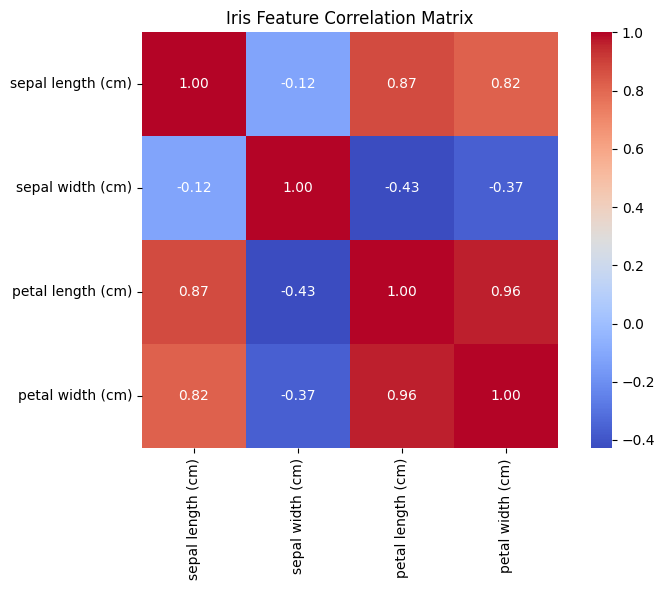

In [72]:
df = pd.DataFrame(x, columns=iris.feature_names)
corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Iris Feature Correlation Matrix")
plt.tight_layout()
plt.show()

## Corrélations entre les 4 paramètres et la classe

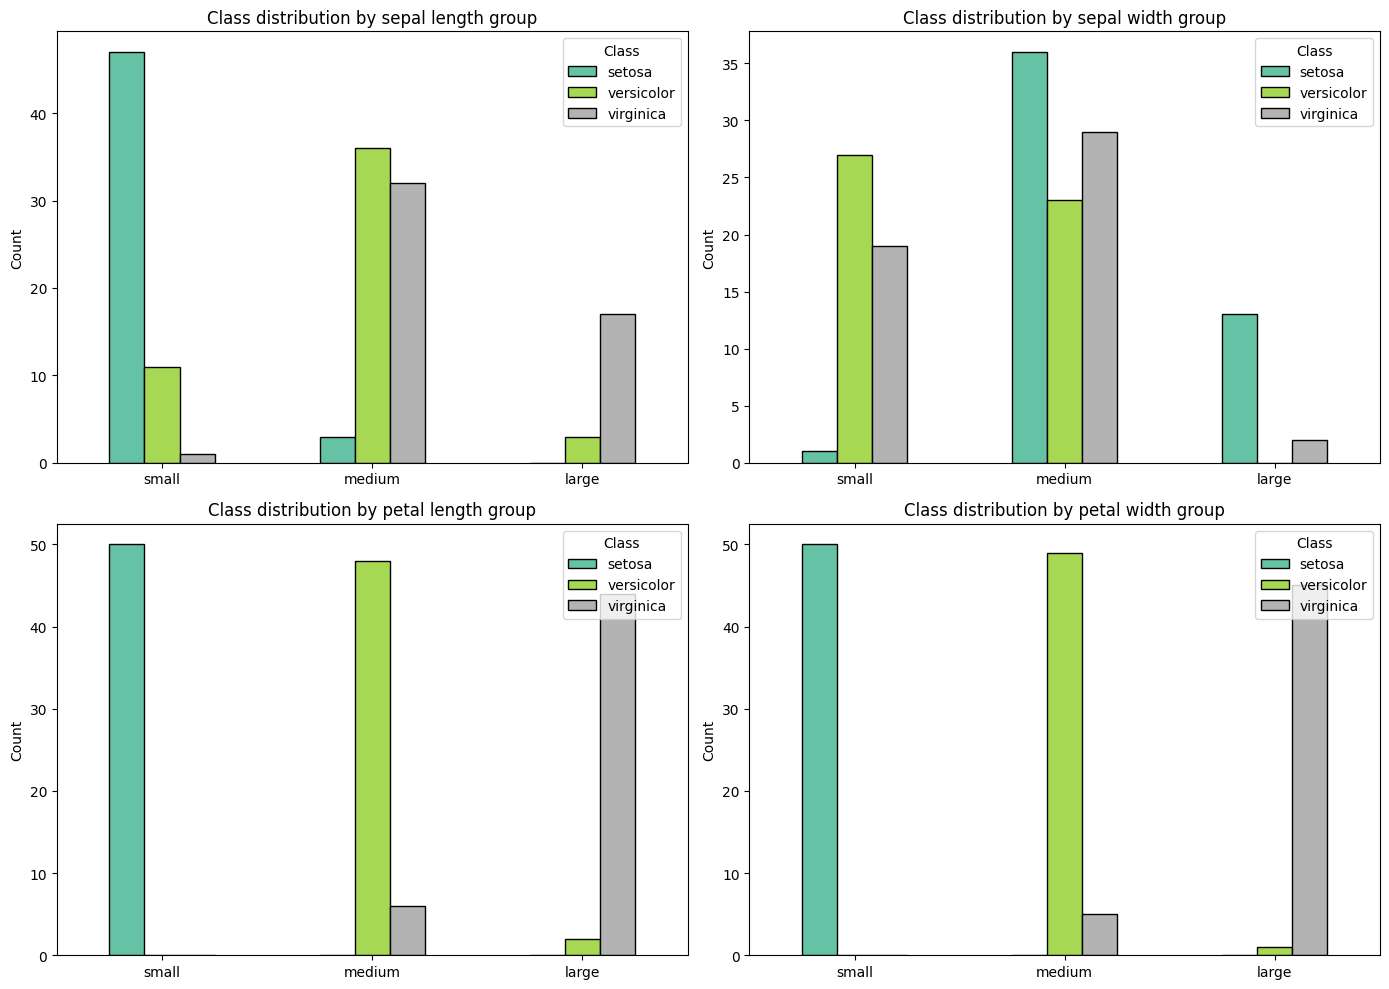

In [73]:
df = pd.DataFrame(x, columns=iris.feature_names)
df["class"] = [iris.target_names[i] for i in y]

features = iris.feature_names
df["sepal length group"] = pd.cut(df["sepal length (cm)"], bins=3, labels=["small", "medium", "large"])
df["sepal width group"]  = pd.cut(df["sepal width (cm)"],  bins=3, labels=["small", "medium", "large"])
df["petal length group"] = pd.cut(df["petal length (cm)"], bins=3, labels=["small", "medium", "large"])
df["petal width group"]  = pd.cut(df["petal width (cm)"],  bins=3, labels=["small", "medium", "large"])

groups = ["sepal length group", "sepal width group", "petal length group", "petal width group"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, group in zip(axes.flat, groups):
    counts = df.groupby([group, "class"], observed=True).size().unstack(fill_value=0)
    counts.plot(kind="bar", ax=ax, colormap="Set2", edgecolor="black")
    ax.set_title(f"Class distribution by {group}")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title="Class")

plt.tight_layout()
plt.show()

## 1er modèle : KNN

Accuracy  : 0.9667 ± 0.0298
F1 (macro): 0.9666 ± 0.0298


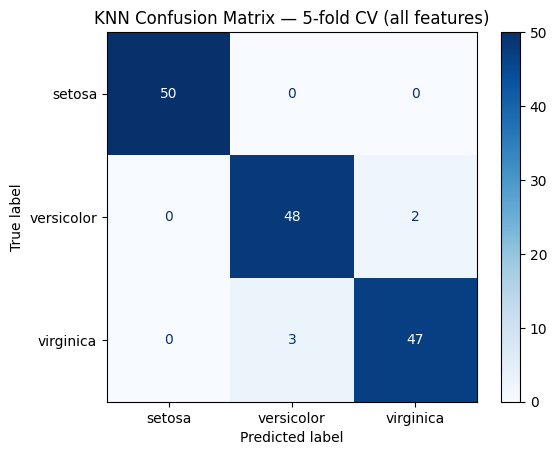

In [74]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

acc_scores = cross_val_score(knn, x, y, cv=cv, scoring="accuracy")
f1_scores  = cross_val_score(knn, x, y, cv=cv, scoring="f1_macro")
y_pred     = cross_val_predict(knn, x, y, cv=cv)

print(f"Accuracy  : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"F1 (macro): {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap="Blues")
plt.title("KNN Confusion Matrix — 5-fold CV (all features)")
plt.show()

## 2ème modèle : Arbre de décision

Accuracy  : 0.9533 ± 0.0340
F1 (macro): 0.9531 ± 0.0341


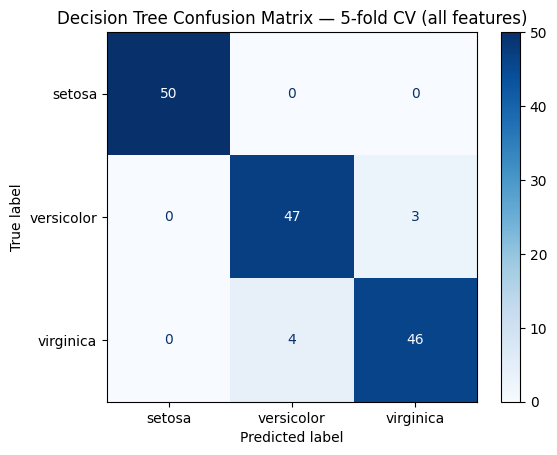

In [75]:
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
dt = DecisionTreeClassifier(random_state=42)

acc_scores = cross_val_score(dt, x, y, cv=cv, scoring="accuracy")
f1_scores  = cross_val_score(dt, x, y, cv=cv, scoring="f1_macro")
y_pred     = cross_val_predict(dt, x, y, cv=cv)

print(f"Accuracy  : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"F1 (macro): {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap="Blues")
plt.title("Decision Tree Confusion Matrix — 5-fold CV (all features)")
plt.show()

## 3ème modèle : Forêt aléatoire

Accuracy  : 0.9467 ± 0.0267
F1 (macro): 0.9464 ± 0.0268


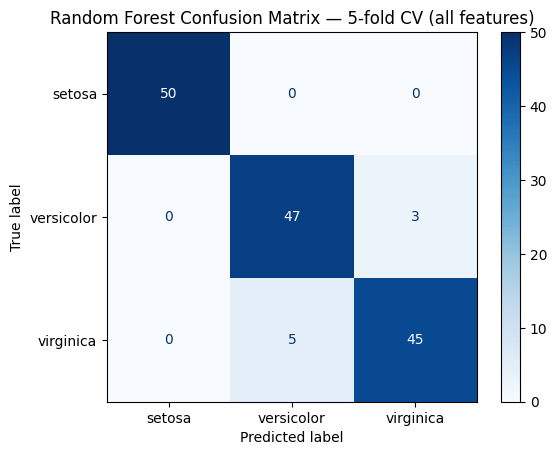

In [76]:
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

acc_scores = cross_val_score(rf, x, y, cv=cv, scoring="accuracy")
f1_scores  = cross_val_score(rf, x, y, cv=cv, scoring="f1_macro")
y_pred     = cross_val_predict(rf, x, y, cv=cv)

print(f"Accuracy  : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}")
print(f"F1 (macro): {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

cm = confusion_matrix(y, y_pred)
ConfusionMatrixDisplay(cm, display_labels=iris.target_names).plot(cmap="Blues")
plt.title("Random Forest Confusion Matrix — 5-fold CV (all features)")
plt.show()

## Conclusion

Dans ce notebook, nous avons exploré le jeu de données Iris et entraîné trois modèles de classification en utilisant une validation croisée à 5 plis sur les 4 caractéristiques (longueur des sépales, largeur des sépales, longueur des pétales, largeur des pétales).

La **validation croisée à 5 plis** consiste à diviser le jeu de données en 5 parties égales. On entraîne le modèle sur 4 parties et on le teste sur la 5ème, puis on répète l'opération 5 fois en changeant à chaque fois la partie utilisée pour le test. Le score final est la moyenne des 5 résultats, ce qui donne une évaluation plus fiable qu'un simple découpage entraînement/test.

### Observations clés de l'analyse exploratoire

- **La longueur et la largeur des pétales** sont fortement corrélées (r ≈ 0,96) et constituent les caractéristiques les plus utiles pour séparer les trois classes.
- **La largeur des sépales** est la moins corrélée aux autres caractéristiques et présente plus de chevauchement entre les classes.
- Les graphiques de distribution des classes confirment que *setosa* est clairement séparée de *versicolor* et *virginica* sur les caractéristiques des pétales, tandis que ces deux dernières se chevauchent davantage.

### Comparaison des modèles (validation croisée à 5 plis)

| Modèle | Exactitude | F1-score (macro) |
|---|---|---|
| KNN (k=5) | 96,67 % | 96,66 % |
| Arbre de décision | 95,33 % | 95,31 % |
| Forêt aléatoire (100 arbres) | 94,67 % | 94,64 % |

### Points clés

- Les trois modèles obtiennent de très bons résultats sur ce jeu de données, avec une exactitude supérieure à 94 % dans tous les cas.
- **KNN (k=5)** obtient les meilleurs résultats (96,67 % d'exactitude), montrant que les classes Iris sont bien séparées dans les 4 caractéristiques et que la classification par proximité est très efficace ici.
- **L'arbre de décision** (95,33 %) arrive en deuxième position, légèrement devant la forêt aléatoire — probablement parce que le jeu de données est assez petit et propre pour qu'un seul arbre généralise bien.
- **La forêt aléatoire** (94,67 %) est légèrement en dessous des deux autres, ce qui peut s'expliquer par l'aléatoire supplémentaire dans la sélection des données pour un si petit jeu de données.
- L'utilisation des 4 caractéristiques surpasse systématiquement l'utilisation de la longueur des pétales seule, car les caractéristiques supplémentaires apportent des informations complémentaires.